# C03 – Encoding & Feature Selection (M3) – Classification
**IT3051 Fundamentals of Data Mining – Mini Project 2026**
**Task:** Classification – predict **`Late_delivery_risk`** at order placement.
**Owner:** M3 – Primesh (Encoding & Frontend)

### The model's features (team decision)
| Feature | Type | Known at order time because |
|---|---|---|
| Shipping Mode | categorical | chosen when ordering |
| Market | categorical | destination region |
| Order Country | categorical (many values) | destination country |
| Category Name | categorical (many values) | what is ordered (Category Id = same information) |
| Order Item Quantity | numeric | how many items |
| Customer Segment | categorical | Consumer / Corporate / Home Office |
| order_weekday, order_month, order_hour, order_quarter, is_weekend | numeric | from the order timestamp (C02) |

**Never used:** Days for shipping (real), Days for shipment (scheduled), Delivery Status, shipping date, Order Status.

### What this notebook does
1. Checks how many values each categorical feature has.
2. Shows that **target encoding leaks** if done wrongly, and is safe inside a pipeline.
3. Compares encoding methods for the many-value columns with grouped cross-validation (main score **ROC-AUC**).
4. Checks what each feature contributes.
5. Saves the **encoding plan** used by C04 – C09 and the backend.

| Input | Output |
|---|---|
| `train_clf_fe.csv`, `test_clf_fe.csv` (C02) | `results/clf_m3_selection.json`, `results/clf_m3_encoding_table.csv`, `results/clf_experiments.csv`, charts in `reports/figures/clf_m3/` |

## Step 0 – Setup
### 0.1 Imports, paths and the feature list

In [4]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, make_scorer, precision_score, recall_score, f1_score

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "reports" / "figures" / "clf_m3"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "Late_delivery_risk"
GROUP = "Order Id"
SEED = 42
LOW_CARD_MAX = 30
FORBIDDEN = ["Days for shipping (real)", "Days for shipment (scheduled)", "Delivery Status",
             "shipping date (DateOrders)", "Order Status", TARGET]

CATEGORY_COL = "Category Name"
DATE_FEATURES = ["order_weekday", "order_month", "order_hour", "order_quarter", "is_weekend"]
BASE_FEATURES = ["Shipping Mode", "Market", "Order Country", CATEGORY_COL, "Order Item Quantity", "Customer Segment"]
FEATURES = BASE_FEATURES + DATE_FEATURES
assert not set(FEATURES) & set(FORBIDDEN), "A forbidden (leaky) column is in the feature list!"

SCORING = {"accuracy": "accuracy", "precision": make_scorer(precision_score, zero_division=0),
           "recall": make_scorer(recall_score, zero_division=0), "f1": make_scorer(f1_score, zero_division=0),
           "roc_auc": "roc_auc"}

def show(fig, name):
    fig.tight_layout(); fig.savefig(FIG_DIR / f"{name}.png", dpi=120); plt.show()

def log_experiment(row, path=RESULTS_DIR / "clf_experiments.csv"):
    new = pd.DataFrame([row])
    out = pd.concat([pd.read_csv(path), new], ignore_index=True) if path.exists() else new
    out.to_csv(path, index=False)

### 0.2 The encoding plan and the preprocessor
Numbers stay numbers; text with **≤ 30** values → **one-hot**; text with **> 30** values → the chosen strategy:

| Strategy | What it does |
|---|---|
| `drop` | leave the many-value columns out (reference only) |
| `onehot` | one 0/1 column per value |
| `onehot_rare` | one-hot for values covering ≥ 1% of rows; rare values share one "infrequent" column |
| `target` | each value → **its late rate**, learned from training data with smoothing |

Unseen values never crash the model: one-hot ignores them, the infrequent bucket catches them, target encoding gives the overall late rate.

In [5]:
def make_plan(X, features, high_card="target"):
    numeric = [f for f in features if pd.api.types.is_numeric_dtype(X[f])]
    cats = [f for f in features if f not in numeric]
    low = [c for c in cats if X[c].nunique() <= LOW_CARD_MAX]
    high = [c for c in cats if c not in low]
    plan = {"numeric": numeric, "onehot": list(low), "onehot_rare": [], "target": [], "dropped": [], "high_card_strategy": high_card}
    if high_card == "onehot":
        plan["onehot"] += high
    elif high_card == "onehot_rare":
        plan["onehot_rare"] = high
    elif high_card == "target":
        plan["target"] = high
    else:
        plan["dropped"] = high
    return plan

def build_preprocessor(plan):
    parts = []
    if plan["numeric"]:
        parts.append(("num", SimpleImputer(strategy="median"), plan["numeric"]))
    if plan["onehot"]:
        parts.append(("onehot", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                          ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), plan["onehot"]))
    if plan["onehot_rare"]:
        parts.append(("onehot_rare", OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist",
                                                   sparse_output=False), plan["onehot_rare"]))
    if plan["target"]:
        parts.append(("target", TargetEncoder(target_type="binary", random_state=SEED), plan["target"]))
    return ColumnTransformer(parts, remainder="drop")

## Step 1 – Load the training data and the grouped CV folds
Folds are **grouped by Order Id** and **stratified on the label** (same % late in every fold), created once and reused.

In [6]:
train = pd.read_csv(PROCESSED_DIR / "train_clf_fe.csv")
if CATEGORY_COL not in train.columns and "Category Id" in train.columns:
    CATEGORY_COL = "Category Id"
    BASE_FEATURES[3] = CATEGORY_COL
    FEATURES = BASE_FEATURES + DATE_FEATURES
if CATEGORY_COL == "Category Id":
    train[CATEGORY_COL] = train[CATEGORY_COL].astype(str)
missing = [f for f in FEATURES if f not in train.columns]
assert not missing, f"Missing columns (run C01 and C02 first): {missing}"

X, y, groups = train.drop(columns=[TARGET]), train[TARGET], train[GROUP]
cv_splits = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(X, y, groups))
print(f"Train: {len(X):,} rows, {groups.nunique():,} orders, late {y.mean() * 100:.1f}% | {len(cv_splits)} grouped folds")
print("Features:", FEATURES)

Train: 138,231 rows, 50,318 orders, late 57.2% | 5 grouped folds
Features: ['Shipping Mode', 'Market', 'Order Country', 'Category Name', 'Order Item Quantity', 'Customer Segment', 'order_weekday', 'order_month', 'order_hour', 'order_quarter', 'is_weekend']


## Step 2 – Categorical features: cardinality, rare and unseen values
### 2.1 Cardinality table

In [7]:
CATS = [f for f in FEATURES if not pd.api.types.is_numeric_dtype(X[f])]
card = pd.DataFrame({
    "n_values": [X[c].nunique() for c in CATS],
    "top_value_%": [X[c].value_counts(normalize=True).iloc[0] * 100 for c in CATS],
    "rare_values_%": [(X[c].value_counts() < 30).mean() * 100 for c in CATS],
    "group": ["low -> one-hot" if X[c].nunique() <= LOW_CARD_MAX else "HIGH -> special" for c in CATS],
}, index=CATS).sort_values("n_values", ascending=False)
HIGH = card.index[card["group"].str.startswith("HIGH")].tolist()
card.round(1)

,n_values,top_value_%,rare_values_%,group
Order Country,161,13.7,28.6,HIGH -> special
Category Name,50,13.6,0.0,HIGH -> special
Market,5,28.6,0.0,low -> one-hot
Shipping Mode,4,59.9,0.0,low -> one-hot
Customer Segment,3,51.8,0.0,low -> one-hot


### 2.2 Long tail of the feature with the most values

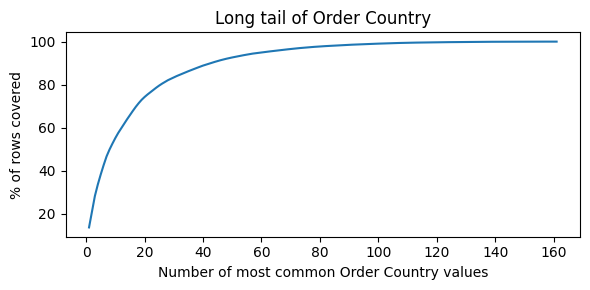

Top   5 values cover 38.3% of rows
Top  10 values cover 55.2% of rows
Top  20 values cover 74.3% of rows
Top  50 values cover 92.6% of rows


In [8]:
col = card.index[0]
coverage = X[col].value_counts(normalize=True).cumsum().reset_index(drop=True) * 100
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.arange(1, len(coverage) + 1), coverage)
ax.set_xlabel(f"Number of most common {col} values"); ax.set_ylabel("% of rows covered"); ax.set_title(f"Long tail of {col}")
show(fig, "01_long_tail")
for n in [5, 10, 20, 50]:
    if n <= len(coverage):
        print(f"Top {n:>3} values cover {coverage.iloc[n - 1]:.1f}% of rows")

### 2.3 Unseen values in validation

In [9]:
unseen = {c: np.mean([(~X[c].iloc[va].isin(set(X[c].iloc[tr]))).mean() * 100 for tr, va in cv_splits]) for c in CATS}
pd.Series(unseen, name="unseen_in_validation_%").round(3).to_frame()

,unseen_in_validation_%
Shipping Mode,0.00
Market,0.00
Order Country,0.02
Category Name,0.00
Customer Segment,0.00


## Step 3 – Target encoding and leakage
**Wrong:** each value's late rate computed on *all* rows, then cross-validated – a row's own label is inside its feature.
**Right:** `TargetEncoder` inside the pipeline – learned from the training folds only, with cross-fitting and smoothing.
The gap in ROC-AUC **is** the leakage.

In [10]:
leak_col = card.index[0]
naive_feature = y.groupby(X[leak_col]).transform("mean").to_frame()                 # WRONG
naive = cross_validate(LogisticRegression(max_iter=1000), naive_feature, y, cv=cv_splits, scoring={"roc_auc": "roc_auc"})
proper = cross_validate(Pipeline([("encode", TargetEncoder(target_type="binary", random_state=SEED)),
                                  ("model", LogisticRegression(max_iter=1000))]),
                        X[[leak_col]], y, cv=cv_splits, scoring={"roc_auc": "roc_auc"})        # RIGHT
pd.Series({"naive (leaky)": naive["test_roc_auc"].mean(), "inside pipeline": proper["test_roc_auc"].mean()},
          name=f"ROC-AUC using only {leak_col}").round(4).to_frame()

,ROC-AUC using only Order Country
naive (leaky),0.5277
inside pipeline,0.5059


## Step 4 – Compare encoding strategies
### 4.1 Cross-validated comparison
Tested with **Logistic Regression** (linear) and **HistGradientBoosting** (trees). Higher ROC-AUC is better.

In [11]:
STRATEGIES = ["drop", "onehot", "onehot_rare", "target"]
MODELS = {
    "Logistic": lambda: Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
    "HistGB": lambda: HistGradientBoostingClassifier(max_iter=200, random_state=SEED),
}

def evaluate(features, strategy, model_name):
    pipe = Pipeline([("prep", build_preprocessor(make_plan(X, features, strategy))), ("model", MODELS[model_name]())])
    s = cross_validate(pipe, X, y, cv=cv_splits, scoring=SCORING)
    out = {m: s[f"test_{m}"].mean() for m in SCORING}
    out["roc_auc_std"] = s["test_roc_auc"].std()
    return out

enc_results = pd.DataFrame([{"strategy": st, "model": m, **evaluate(FEATURES, st, m)} for st in STRATEGIES for m in MODELS])
enc_results.round(4)

,strategy,model,accuracy,precision,recall,f1,roc_auc,roc_auc_std
0,drop,Logistic,0.7168,0.8925,0.5739,0.6985,0.7445,0.0038
1,drop,HistGB,0.7165,0.8593,0.6029,0.7086,0.7692,0.0041
2,onehot,Logistic,0.7110,0.8730,0.5789,0.6961,0.7449,0.0037
3,onehot,HistGB,0.7151,0.8560,0.6032,0.7077,0.7680,0.0044
4,onehot_rare,Logistic,0.7154,0.8907,0.5726,0.6970,0.7452,0.0040
5,onehot_rare,HistGB,0.7145,0.8564,0.6017,0.7067,0.7696,0.0036
6,target,Logistic,0.7141,0.8848,0.5750,0.6970,0.7450,0.0034
7,target,HistGB,0.7173,0.8635,0.6006,0.7084,0.7720,0.0039


### 4.2 Comparison chart

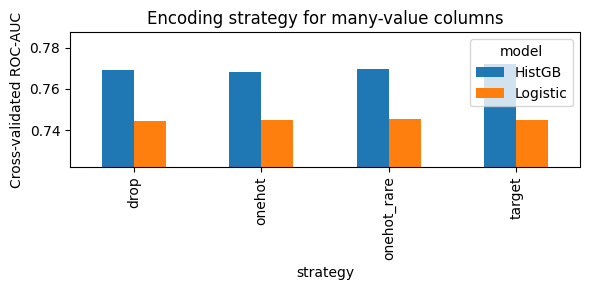

In [12]:
pivot = enc_results.pivot(index="strategy", columns="model", values="roc_auc").loc[STRATEGIES]
ax = pivot.plot.bar(figsize=(6, 3))
ax.set_ylabel("Cross-validated ROC-AUC"); ax.set_title("Encoding strategy for many-value columns")
ax.set_ylim(pivot.min().min() * 0.97, pivot.max().max() * 1.02)
show(ax.figure, "02_encoding_comparison")

### 4.3 Choose the strategy
The team keeps Order Country and Category Name, so the final strategy is the best one **that keeps them** (`drop` is a reference only).

In [13]:
best = enc_results[enc_results["strategy"] != "drop"].sort_values("roc_auc", ascending=False).iloc[0]
BEST_STRATEGY = best["strategy"]
drop_best = enc_results[enc_results["strategy"] == "drop"]["roc_auc"].max()
print(f"Chosen: {BEST_STRATEGY} (best with {best['model']}, ROC-AUC {best['roc_auc']:.4f} ± {best['roc_auc_std']:.4f})")
print(f"Reference without the many-value columns: ROC-AUC {drop_best:.4f}")

Chosen: target (best with HistGB, ROC-AUC 0.7720 ± 0.0039)
Reference without the many-value columns: ROC-AUC 0.7692


## Step 5 – Check the feature list
### 5.1 Drop-column importance
Retrain on one fold without each feature (the 5 date features as one group). Importance = how much the ROC-AUC **falls** when it is removed.

In [14]:
tr_idx, va_idx = cv_splits[0]
UNITS = {f: [f] for f in BASE_FEATURES}
UNITS["date features"] = DATE_FEATURES

def fold_auc(features):
    pipe = Pipeline([("prep", build_preprocessor(make_plan(X, features, BEST_STRATEGY))),
                     ("model", HistGradientBoostingClassifier(max_iter=200, random_state=SEED))])
    pipe.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    return roc_auc_score(y.iloc[va_idx], pipe.predict_proba(X.iloc[va_idx])[:, 1])

base_auc = fold_auc(FEATURES)
importance = pd.Series({u: base_auc - fold_auc([f for f in FEATURES if f not in cols]) for u, cols in UNITS.items()},
                       name="ROC-AUC drop when removed").sort_values(ascending=False)
print(f"Validation ROC-AUC with all features: {base_auc:.4f}")
importance.round(4).to_frame()

Validation ROC-AUC with all features: 0.7690


,ROC-AUC drop when removed
Shipping Mode,0.2482
date features,0.0326
Order Country,0.0059
Customer Segment,0.0043
Category Name,0.0019
Order Item Quantity,0.0018
Market,0.0009


### 5.2 Importance chart

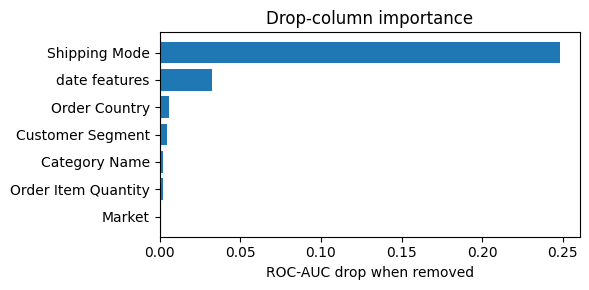

In [15]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(importance.index[::-1], importance.values[::-1]); ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("ROC-AUC drop when removed"); ax.set_title("Drop-column importance")
show(fig, "03_drop_column_importance")

### 5.3 Team list vs simpler alternatives

In [16]:
ALTERNATIVES = {"Shipping Mode only": ["Shipping Mode"], "team list without date features": BASE_FEATURES, "team list (FINAL)": FEATURES}
feature_sets = pd.DataFrame([{"feature_set": n, "n_features": len(fs), "model": m, **evaluate(fs, BEST_STRATEGY, m)}
                             for n, fs in ALTERNATIVES.items() for m in MODELS])
feature_sets.round(4)

,feature_set,n_features,model,accuracy,precision,recall,f1,roc_auc,roc_auc_std
0,Shipping Mode only,1,Logistic,0.6968,0.8868,0.5385,0.6701,0.7414,0.0032
1,Shipping Mode only,1,HistGB,0.6968,0.8868,0.5385,0.6701,0.7414,0.0032
2,team list without date features,6,Logistic,0.6959,0.8748,0.5465,0.6727,0.7409,0.0043
3,team list without date features,6,HistGB,0.6941,0.8565,0.5588,0.6763,0.7429,0.0035
4,team list (FINAL),11,Logistic,0.7141,0.8848,0.5750,0.6970,0.7450,0.0034
5,team list (FINAL),11,HistGB,0.7173,0.8635,0.6006,0.7084,0.7720,0.0039


## Step 6 – The final encoding
### 6.1 Fit on train, transform test

In [17]:
PLAN = make_plan(X, FEATURES, BEST_STRATEGY)
final_prep = build_preprocessor(PLAN)
Xt_tr = final_prep.fit_transform(X, y)
test = pd.read_csv(PROCESSED_DIR / "test_clf_fe.csv")
if CATEGORY_COL == "Category Id":
    test[CATEGORY_COL] = test[CATEGORY_COL].astype(str)
Xt_te = final_prep.transform(test.drop(columns=[TARGET]))
out_names = final_prep.get_feature_names_out()
print("Train matrix:", Xt_tr.shape, "| Test matrix:", Xt_te.shape, "| missing:", bool(np.isnan(Xt_tr).any() or np.isnan(Xt_te).any()))

Train matrix: (138231, 20) | Test matrix: (34534, 20) | missing: False


### 6.2 How each feature is encoded

In [18]:
def n_cols(f):
    return sum(n.split("__", 1)[1] == f or n.split("__", 1)[1].startswith(f + "_") for n in out_names)

def how(f):
    for key, label in [("numeric", "number (as is)"), ("onehot", "one-hot"), ("onehot_rare", "one-hot + rare bucket"), ("target", "target encoding (late rate)")]:
        if f in PLAN[key]:
            return label
    return "dropped"

encoding_table = pd.DataFrame({"different_values": [X[f].nunique() for f in FEATURES],
                               "encoding": [how(f) for f in FEATURES],
                               "model_columns": [n_cols(f) for f in FEATURES]}, index=FEATURES)
encoding_table.to_csv(RESULTS_DIR / "clf_m3_encoding_table.csv")
print(f"Total columns the model receives: {len(out_names)}")
encoding_table

Total columns the model receives: 20


,different_values,encoding,model_columns
Shipping Mode,4,one-hot,4
Market,5,one-hot,5
Order Country,161,target encoding (late rate),1
Category Name,50,target encoding (late rate),1
Order Item Quantity,5,number (as is),1
Customer Segment,3,one-hot,3
order_weekday,7,number (as is),1
order_month,12,number (as is),1
order_hour,24,number (as is),1
order_quarter,4,number (as is),1


### 6.3 What the target encoder learned
For the busiest values: rows, plain late rate, and the number the model receives (rare values are pulled towards the overall late rate).

In [19]:
if PLAN["target"]:
    te = final_prep.named_transformers_["target"]
    for col, cats, enc in zip(PLAN["target"], te.categories_, te.encodings_):
        learned = pd.Series(enc, index=cats)
        top = X[col].value_counts().head(5).index
        print(f"\n{col}: {len(cats):,} values -> 1 column | unseen value -> {te.target_mean_:.3f}")
        print(pd.DataFrame({"rows_in_train": X[col].value_counts()[top],
                            "raw_late_rate": y.groupby(X[col]).mean()[top].round(3),
                            "encoded_value": learned[top].round(3)}))
else:
    print(f"Strategy is '{BEST_STRATEGY}' - no target encoding used")


Order Country: 161 values -> 1 column | unseen value -> 0.572
                rows_in_train  raw_late_rate  encoded_value
Order Country                                              
Estados Unidos          18914          0.576          0.576
Francia                 10116          0.578          0.578
México                  10039          0.574          0.574
Alemania                 7374          0.595          0.595
Australia                6467          0.564          0.564

Category Name: 50 values -> 1 column | unseen value -> 0.572
                      rows_in_train  raw_late_rate  encoded_value
Category Name                                                    
Cleats                        18833          0.575          0.575
Men's Footwear                17059          0.571          0.571
Women's Apparel               16120          0.570          0.570
Indoor/Outdoor Games          14769          0.568          0.568
Fishing                       13223          0.572         

## Step 7 – Save the decision and log the experiments

In [20]:
decision = {"task": "classification", "target": TARGET, "features": FEATURES, "category_column": CATEGORY_COL,
            "date_features": DATE_FEATURES, "not_used": FORBIDDEN, "low_card_max": LOW_CARD_MAX, "plan": PLAN,
            "cv": "StratifiedGroupKFold(5) grouped by Order Id", "n_model_columns": int(len(out_names)),
            "cv_roc_auc_final_features": {r["model"]: round(float(r["roc_auc"]), 4)
                                          for _, r in feature_sets[feature_sets["feature_set"] == "team list (FINAL)"].iterrows()}}
(RESULTS_DIR / "clf_m3_selection.json").write_text(json.dumps(decision, indent=2, ensure_ascii=False), encoding="utf-8")

for _, r in enc_results.iterrows():
    log_experiment({"owner": "M3", "experiment": f"encoding_{r['strategy']}", "model": r["model"], "n_features": len(FEATURES),
                    **{m: r[m] for m in SCORING}, "roc_auc_std": r["roc_auc_std"]})
for _, r in feature_sets.iterrows():
    log_experiment({"owner": "M3", "experiment": f"features_{r['feature_set']}", "model": r["model"], "n_features": r["n_features"],
                    **{m: r[m] for m in SCORING}, "roc_auc_std": r["roc_auc_std"]})
print("Saved clf_m3_selection.json and clf_m3_encoding_table.csv")

Saved clf_m3_selection.json and clf_m3_encoding_table.csv


## Step 8 – Viva summary

In [21]:
fin = feature_sets[feature_sets["feature_set"] == "team list (FINAL)"].set_index("model")["roc_auc"]
print(f'''
FEATURES         {", ".join(FEATURES)}
MANY-VALUE COLS  {", ".join(f"{c} ({X[c].nunique():,})" for c in HIGH) or "none"}
LEAKAGE DEMO     naive ROC-AUC {naive["test_roc_auc"].mean():.3f} vs inside pipeline {proper["test_roc_auc"].mean():.3f}
ENCODING         {BEST_STRATEGY} (ROC-AUC {best["roc_auc"]:.4f}); without those columns {drop_best:.4f}
MOST IMPORTANT   {", ".join(importance.index[:3])}
FINAL CV ROC-AUC Logistic {fin["Logistic"]:.4f} | HistGB {fin["HistGB"]:.4f}
MODEL COLUMNS    {len(out_names)}
''')


FEATURES         Shipping Mode, Market, Order Country, Category Name, Order Item Quantity, Customer Segment, order_weekday, order_month, order_hour, order_quarter, is_weekend
MANY-VALUE COLS  Order Country (161), Category Name (50)
LEAKAGE DEMO     naive ROC-AUC 0.528 vs inside pipeline 0.506
ENCODING         target (ROC-AUC 0.7720); without those columns 0.7692
MOST IMPORTANT   Shipping Mode, date features, Order Country
FINAL CV ROC-AUC Logistic 0.7450 | HistGB 0.7720
MODEL COLUMNS    20



**My contribution in one sentence:** I chose how every categorical feature is encoded, showed that target encoding is safe only inside
the pipeline, and checked what each feature contributes to predicting late delivery.